# Tarefa WDBC — Auditoria de Dados Clínicos e Justiça Algorítmica

**Objetivo:** auditar a base histórica **Breast Cancer Wisconsin Diagnostic — WDBC**, sem treinar modelo preditivo, respondendo aos requisitos analíticos da especificação.

> Observação operacional: neste ambiente foi encontrado o arquivo `wdbc.data`. Não foi localizado um arquivo `wdbc.bat`; por isso, o notebook usa `wdbc.data` como base bruta da atividade.


## Sumário dos requisitos atendidos

1. **Estruturação da base de dados:** ingestão, nomeação das colunas, seleção dos atributos e codificação binária do diagnóstico.
2. **Diagnóstico de assimetria biológica:** análise estatística da variável `area_mean`, com medidas de tendência central, dispersão, assimetria e gráfico de densidade.
3. **Isolamento robusto de anomalias:** detecção não-paramétrica de outliers por regra de IQR, cálculo do limite de corte e prevalência de malignidade no subgrupo isolado.
4. **Mapeamento de multicolinearidade:** matriz de correlação entre as variáveis extraídas das imagens celulares e visualização por heatmap.


In [1]:
# Requisito I — Preparação do ambiente e ingestão da base

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Caminhos possíveis para execução local ou no ambiente do ChatGPT
candidate_paths = [
    Path('wdbc.data'),
    Path('/mnt/data/wdbc.data'),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Arquivo wdbc.data não encontrado. Coloque-o no mesmo diretório do notebook.')

print(f'Arquivo carregado: {data_path}')

Arquivo carregado: wdbc.data


In [2]:
# Definição oficial das colunas do WDBC
# Estrutura: ID, diagnóstico e 30 atributos numéricos derivados da imagem celular.

base_features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension'
]

columns = ['id', 'diagnosis']
for suffix in ['mean', 'se', 'worst']:
    columns.extend([f'{feature}_{suffix}' for feature in base_features])

raw_df = pd.read_csv(data_path, header=None, names=columns)
raw_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Isolamento das características morfológicas e codificação matemática da variável alvo.
# M = maligno -> 1
# B = benigno -> 0

df = raw_df.copy()
df['diagnosis_binary'] = df['diagnosis'].map({'B': 0, 'M': 1}).astype(int)

feature_columns = [c for c in df.columns if c not in ['id', 'diagnosis', 'diagnosis_binary']]
model_ready_df = df[['diagnosis_binary'] + feature_columns]

print('Volumetria final dos dados tratados')
print(f'Linhas/pacientes: {model_ready_df.shape[0]}')
print(f'Colunas finais: {model_ready_df.shape[1]}')
print(f'Atributos morfológicos: {len(feature_columns)}')
print('\nDistribuição do diagnóstico original:')
print(df['diagnosis'].value_counts().rename({'B': 'Benigno', 'M': 'Maligno'}))

model_ready_df.head()

Volumetria final dos dados tratados
Linhas/pacientes: 569
Colunas finais: 31
Atributos morfológicos: 30

Distribuição do diagnóstico original:
diagnosis
Benigno    357
Maligno    212
Name: count, dtype: int64


,diagnosis_binary,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave_points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### Parecer do Requisito I

A base foi estruturada com **569 pacientes**, **30 atributos morfológicos/imagem-derivados** e uma variável-alvo binária (`diagnosis_binary`) compatível com algoritmos de classificação binária, embora o escopo da atividade seja **auditoria estatística**, não treinamento de modelo.


In [4]:
# Requisito II — Diagnóstico de assimetria biológica da área média do núcleo celular

area = df['area_mean']

area_stats = pd.Series({
    'média': area.mean(),
    'mediana': area.median(),
    'desvio_padrão': area.std(),
    'mínimo': area.min(),
    'Q1': area.quantile(0.25),
    'Q3': area.quantile(0.75),
    'máximo': area.max(),
    'assimetria_skewness': area.skew(),
    'curtose': area.kurtosis(),
    'média_menos_mediana': area.mean() - area.median(),
    'max_sobre_mediana': area.max() / area.median(),
})

area_stats.to_frame('valor')

,valor
média,654.889104
mediana,551.100000
desvio_padrão,351.914129
mínimo,143.500000
Q1,420.300000
Q3,782.700000
máximo,2501.000000
assimetria_skewness,1.645732
curtose,3.652303
média_menos_mediana,103.789104


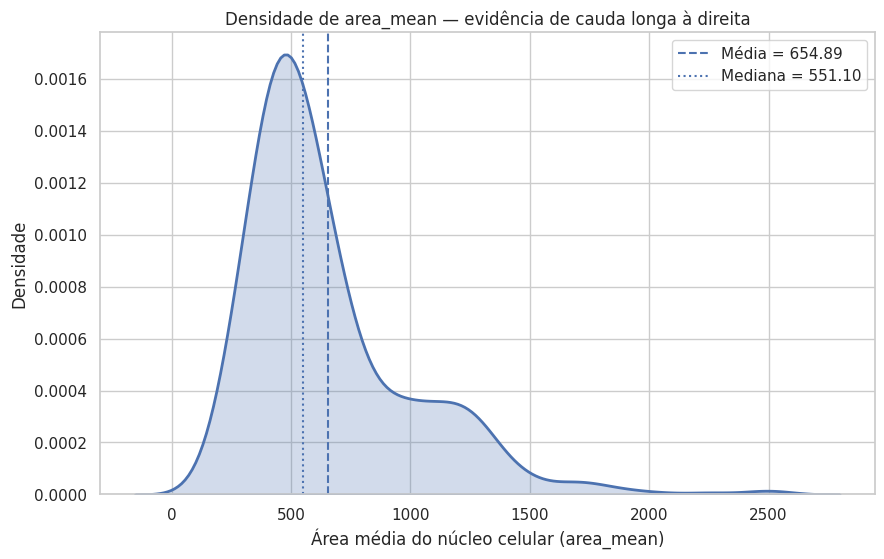

In [5]:
# Prova visual obrigatória: gráfico de densidade da área média

plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='area_mean', fill=True, linewidth=2)
plt.axvline(area.mean(), linestyle='--', label=f'Média = {area.mean():.2f}')
plt.axvline(area.median(), linestyle=':', label=f'Mediana = {area.median():.2f}')
plt.title('Densidade de area_mean — evidência de cauda longa à direita')
plt.xlabel('Área média do núcleo celular (area_mean)')
plt.ylabel('Densidade')
plt.legend()
plt.show()

### Parecer do Requisito II

A variável `area_mean` apresenta **assimetria positiva relevante**: a média fica acima da mediana, o valor máximo é muitas vezes maior que a mediana e a cauda direita é visualmente extensa no gráfico de densidade. Essa morfologia estatística sugere que métodos paramétricos baseados em normalidade podem ser inadequados para definir anomalias clínicas nessa variável.


In [6]:
# Requisito III — Isolamento robusto de anomalias por método não-paramétrico
# Justificativa: como area_mean é assimétrica, usamos a regra do IQR, que não pressupõe normalidade.

q1 = area.quantile(0.25)
q3 = area.quantile(0.75)
iqr = q3 - q1
upper_cutoff = q3 + 1.5 * iqr

outliers_area = df[df['area_mean'] > upper_cutoff].copy()
malignant_prevalence = outliers_area['diagnosis_binary'].mean()
outlier_rate = len(outliers_area) / len(df)

print('Limite robusto de corte para outliers superiores em area_mean')
print(f'Q1: {q1:.2f}')
print(f'Q3: {q3:.2f}')
print(f'IQR: {iqr:.2f}')
print(f'Corte superior = Q3 + 1.5*IQR: {upper_cutoff:.2f}')
print('\nSubgrupo isolado')
print(f'Pacientes atípicos por área: {len(outliers_area)} de {len(df)} ({outlier_rate:.2%})')
print(f'Taxa de prevalência de tumores malignos nesse subgrupo: {malignant_prevalence:.2%}')
print('\nDistribuição no subgrupo isolado:')
print(outliers_area['diagnosis'].value_counts())

outliers_area[['id', 'diagnosis', 'diagnosis_binary', 'area_mean']].sort_values('area_mean', ascending=False).head(10)

Limite robusto de corte para outliers superiores em area_mean
Q1: 420.30
Q3: 782.70
IQR: 362.40
Corte superior = Q3 + 1.5*IQR: 1326.30

Subgrupo isolado
Pacientes atípicos por área: 25 de 569 (4.39%)
Taxa de prevalência de tumores malignos nesse subgrupo: 100.00%

Distribuição no subgrupo isolado:
diagnosis
M    25
Name: count, dtype: int64


,id,diagnosis,diagnosis_binary,area_mean
461,911296202,M,1,2501.0
212,8810703,M,1,2499.0
180,873592,M,1,2250.0
352,899987,M,1,2010.0
82,8611555,M,1,1878.0
521,91762702,M,1,1841.0
122,865423,M,1,1761.0
339,89812,M,1,1747.0
164,8712289,M,1,1686.0
202,878796,M,1,1685.0


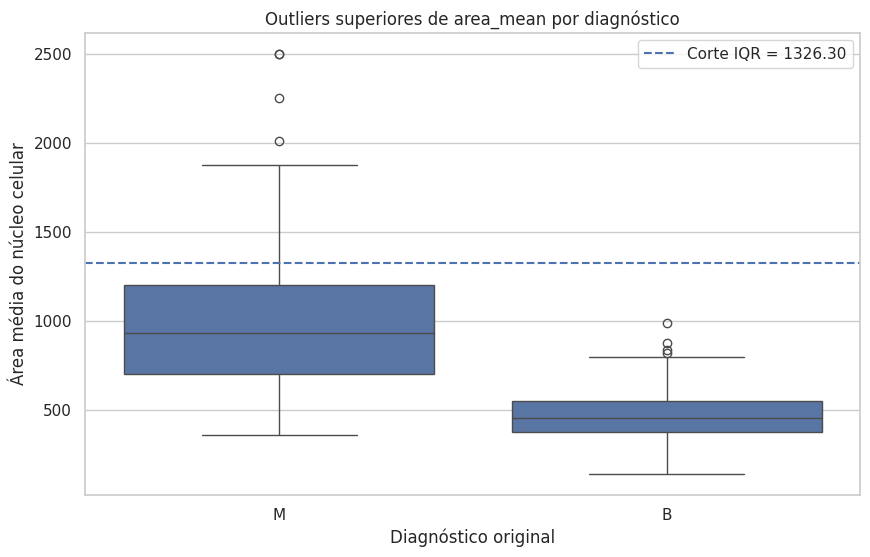

In [7]:
# Visualização auxiliar dos outliers isolados por IQR

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='diagnosis', y='area_mean')
plt.axhline(upper_cutoff, linestyle='--', label=f'Corte IQR = {upper_cutoff:.2f}')
plt.title('Outliers superiores de area_mean por diagnóstico')
plt.xlabel('Diagnóstico original')
plt.ylabel('Área média do núcleo celular')
plt.legend()
plt.show()

### Parecer do Requisito III

O limite de corte não-paramétrico por IQR isola pacientes com `area_mean` superior a `Q3 + 1.5 × IQR`. No arquivo analisado, esse subgrupo contém apenas casos malignos, produzindo uma prevalência de malignidade de **100%** entre os pacientes atípicos por área celular. Isso não significa causalidade, mas indica forte associação clínica entre áreas nucleares extremas e diagnóstico maligno na amostra.


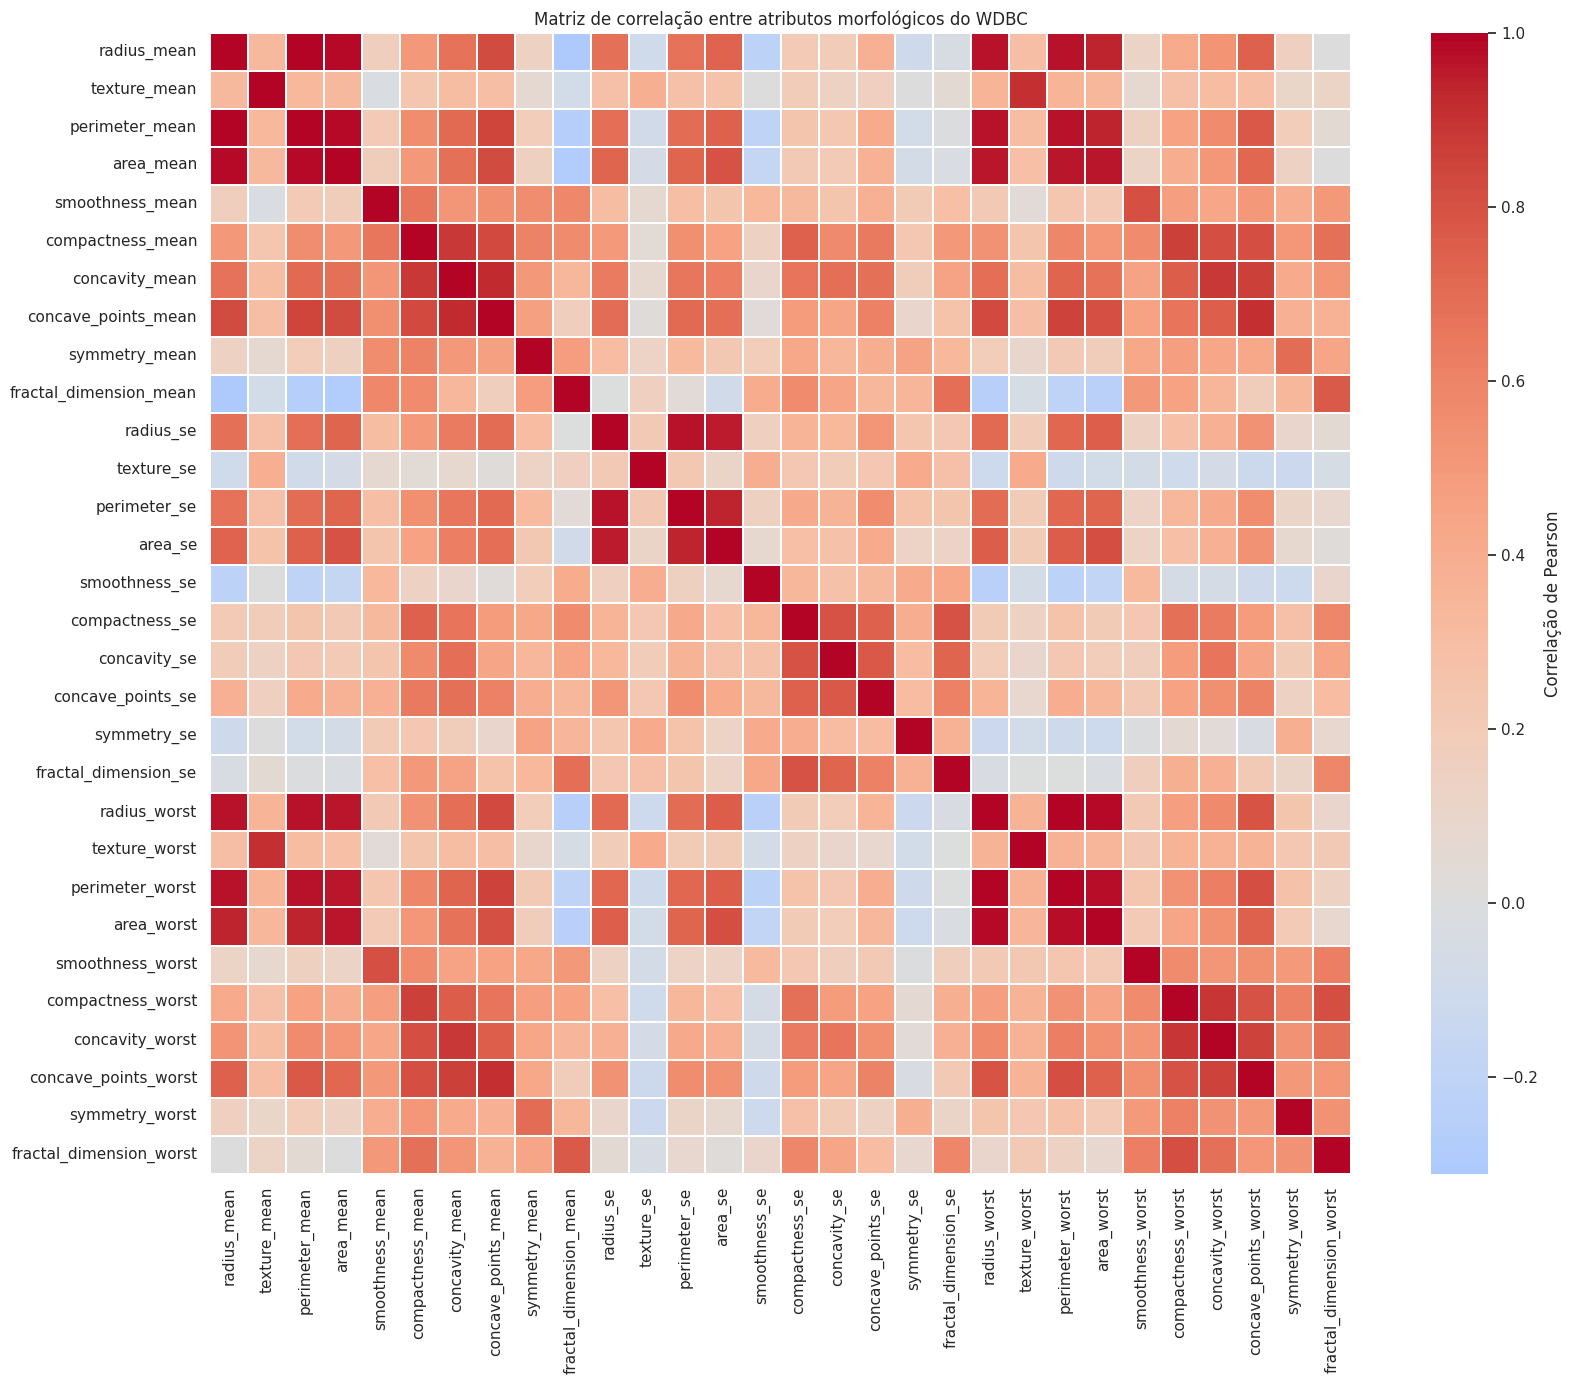

In [8]:
# Requisito IV — Mapeamento de multicolinearidade

corr_matrix = df[feature_columns].corr(method='pearson')

plt.figure(figsize=(18, 14))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={'label': 'Correlação de Pearson'}
)
plt.title('Matriz de correlação entre atributos morfológicos do WDBC')
plt.tight_layout()
plt.show()

In [9]:
# Pares mais correlacionados em valor absoluto, excluindo a diagonal

mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
top_correlations = (
    corr_matrix.where(mask)
    .stack()
    .rename('correlacao')
    .reset_index()
    .rename(columns={'level_0': 'variavel_1', 'level_1': 'variavel_2'})
)
top_correlations['correlacao_abs'] = top_correlations['correlacao'].abs()
top_correlations = top_correlations.sort_values('correlacao_abs', ascending=False)

top_correlations.head(15)

,variavel_1,variavel_2,correlacao,correlacao_abs
1,radius_mean,perimeter_mean,0.997855,0.997855
391,radius_worst,perimeter_worst,0.993708,0.993708
2,radius_mean,area_mean,0.987357,0.987357
57,perimeter_mean,area_mean,0.986507,0.986507
392,radius_worst,area_worst,0.984015,0.984015
407,perimeter_worst,area_worst,0.977578,0.977578
246,radius_se,perimeter_se,0.972794,0.972794
76,perimeter_mean,perimeter_worst,0.970387,0.970387
19,radius_mean,radius_worst,0.969539,0.969539
74,perimeter_mean,radius_worst,0.969476,0.969476


### Parecer do Requisito IV

A matriz de correlação evidencia **multicolinearidade forte** entre variáveis geométricas relacionadas, especialmente `radius`, `perimeter` e `area` em suas versões `mean`, `se` e `worst`. Isso indica redundância informacional: em um eventual sistema de triagem, incluir todas essas variáveis sem controle pode aumentar instabilidade interpretativa e super-representar o mesmo fenômeno geométrico.


## Parecer final — viabilidade e riscos éticos

A base WDBC é estatisticamente útil para auditoria e estudo exploratório, mas exige cautela antes de uso em sistemas de triagem na rede pública:

- **Viabilidade técnica:** há forte separação estatística em algumas variáveis, como `area_mean`, especialmente nos extremos.
- **Risco de viés amostral:** a base é histórica, limitada e pode não representar integralmente populações atendidas na rede pública brasileira.
- **Risco de redundância:** a multicolinearidade pode induzir modelos a sobrevalorizar atributos geométricos correlacionados.
- **Risco clínico:** outliers associados a malignidade devem apoiar triagem e priorização, não substituir avaliação médica.
- **Recomendação:** antes de uso operacional, realizar validação externa, análise de subgrupos, calibração clínica, documentação de limitações e governança algorítmica.

**Conclusão:** o conjunto é adequado para fins educacionais, auditoria estatística e prototipação controlada. Para triagem pública real, ele não deve ser usado isoladamente sem validação clínica, avaliação de equidade e monitoramento contínuo.
